In [2]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras

In [3]:
from keras.models import Sequential, Model
from keras.layers import (
    Dense, Input, ReLU, Flatten, Rescaling, Convolution2D
    , Reshape, MaxPooling2D
)
from keras.losses import SparseCategoricalCrossentropy, CategoricalCrossentropy
from keras.metrics import Accuracy
from keras.optimizers import Adam

from keras.datasets import mnist

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=1)
print(f'{x_train.shape} - {x_val.shape}')

(48000, 28, 28) - (12000, 28, 28)


In [6]:
print(233/255)
print(233*(1/255))

0.9137254901960784
0.9137254901960784


In [7]:
def build_cnn_model() -> Sequential:
    model = Sequential([
        Input((28, 28))
        , Reshape((28, 28, 1))
        , Rescaling(1./255)

        , Convolution2D(
            filters=32, kernel_size=(2, 2), activation='relu'
            , strides=(1, 1), padding='same'
            )
        , Convolution2D(32, 2, 1, 'same', activation='relu')
        , MaxPooling2D((2, 2))

        , Convolution2D(64, 2, 1, 'same', activation='relu')
        , Convolution2D(64, 2, 1, 'same', activation='relu')
        , MaxPooling2D((2, 2))

        , Convolution2D(64, 2, 1, 'same', activation='relu')
        , Convolution2D(64, 2, 1, 'same', activation='relu')
        , MaxPooling2D((2, 2))

        , Convolution2D(64, 2, 1, 'same', activation='relu')
        , Convolution2D(64, 2, 1, 'same', activation='relu')
        , MaxPooling2D((2, 2))

        , Flatten()
        , Dense(128, activation='relu')
        , Dense(10, activation='softmax')

    ])

    model.compile(
        optimizer=Adam(), loss=SparseCategoricalCrossentropy
        , metrics=['accuracy']
        )

    return model

cnn = build_cnn_model()
cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 3, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,394 (407.79 KB)

 Trainable params: 104,394 (407.79 KB)

 Non-trainable params: 0 (0.00 B)

/tmp/ipykernel_82347/129707683.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sns.kdeplot(np.array(cnn.layers[-1].weights[0]).ravel())


<Axes: ylabel='Density'>

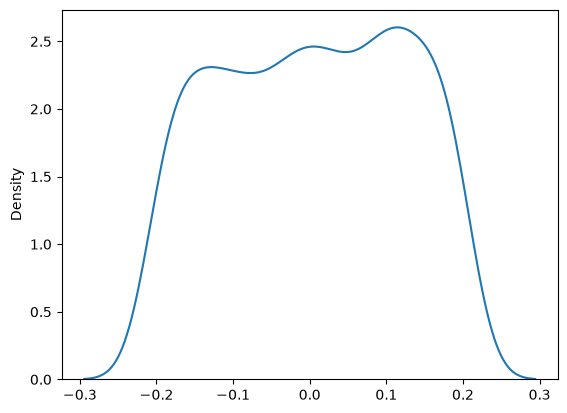

In [8]:
sns.kdeplot(np.array(cnn.layers[-1].weights[0]).ravel())

In [9]:
for idx, layer in enumerate(cnn.layers):
    print(f'{idx} - {layer.name}')

0 - reshape
1 - rescaling
2 - conv2d
3 - conv2d_1
4 - max_pooling2d
5 - conv2d_2
6 - conv2d_3
7 - max_pooling2d_1
8 - conv2d_4
9 - conv2d_5
10 - max_pooling2d_2
11 - conv2d_6
12 - conv2d_7
13 - max_pooling2d_3
14 - flatten
15 - dense
16 - dense_1


In [18]:
# feature maps
f_map_extractor = Model(inputs=cnn.inputs, outputs=[cnn.layers[4].output, cnn.layers[-1].output])
f_map = f_map_extractor.predict(x_test)
f_map



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


[array([[[[0.        , 0.        , 0.        , ..., 0.        ,
           0.        , 0.        ],
          [0.        , 0.        , 0.        , ..., 0.        ,
           0.        , 0.        ],
          [0.        , 0.        , 0.        , ..., 0.        ,
           0.        , 0.        ],
          ...,
          [0.        , 0.        , 0.        , ..., 0.        ,
           0.        , 0.        ],
          [0.        , 0.        , 0.        , ..., 0.        ,
           0.        , 0.        ],
          [0.        , 0.        , 0.        , ..., 0.        ,
           0.        , 0.        ]],
 
         [[0.        , 0.        , 0.        , ..., 0.        ,
           0.        , 0.        ],
          [0.        , 0.        , 0.        , ..., 0.        ,
           0.        , 0.        ],
          [0.        , 0.        , 0.        , ..., 0.        ,
           0.        , 0.        ],
          ...,
          [0.        , 0.        , 0.        , ..., 0.        ,
   

In [19]:
f_map[-1]

array([[0.10011614, 0.09948756, 0.1023222 , ..., 0.09914064, 0.10049234,
        0.10071323],
       [0.09988387, 0.10029765, 0.102153  , ..., 0.09950578, 0.10073201,
        0.10042652],
       [0.09993366, 0.09993923, 0.10157354, ..., 0.09979511, 0.09990101,
        0.10079059],
       ...,
       [0.09993695, 0.09970655, 0.10201255, ..., 0.09958673, 0.10028137,
        0.10077681],
       [0.09993109, 0.10015948, 0.10161189, ..., 0.09984789, 0.10012566,
        0.10064786],
       [0.10024359, 0.10030991, 0.10206302, ..., 0.09947378, 0.10045569,
        0.10057689]], shape=(10000, 10), dtype=float32)

In [20]:
f_map[0][:, :, 0]

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

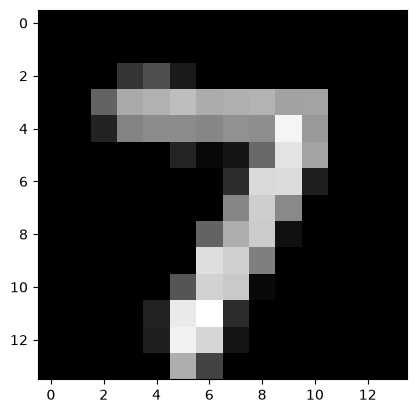

In [22]:
# plt.imshow(x_test[0], cmap='gray')
# plt.show()

#plt.imshow(f_map[0][:, :, 7])

plt.imshow(f_map[0][0, :, :, 7], cmap='gray')
plt.show()